PRÁCTICA MACHINE LEARNING: Predecir el mercado de valores

 ¡Hola y bienvenido a la Práctica de Machine Learning más difícil del mundo!

Este notebook está diseñado para ayudarte a comenzar con la práctica.

En este cuaderno vamos a:

- Descargar y explorar el conjunto de datos
- Entrenar y evaluar este primer modelo de aprendizaje automático
- Implementar el modelo para comenzar a realizar predicciones

In [144]:
# Instala dependencias
!pip install -q --upgrade numerapi pandas pyarrow matplotlib lightgbm scikit-learn scipy cloudpickle==3.1.1
!pip install -q --no-deps numerai-tools

# Gráficas Inline
%matplotlib inline


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


1.- DATASET

A alto nivel, trabajaremos con un conjunto de datos tabulares que describe el mercado de valores a lo largo del tiempo.

Cada fila representa una acción en un momento específico, donde "id" es la identificación de la acción y "era" es la fecha. 

Las características describen los atributos de la acción (por ejemplo, el ratio Price/Earning) conocidos en una fecha dada, y "target" es una medida de rendimientos a 20 días.

El conjunto de datos está ofuscado, lo que significa que los identificadores de acciones (stocks) subyacentes, los nombres de las características y las definiciones de objetivos son anónimos. Esto hace que podamos trabajar con estos datos de forma gratuita y que puedan modelarse sin ningún conocimiento (¡o sesgo!) del dominio financiero.

Descargamos los datos históricos de entrenamiento y echamos un vistazo de cerca.

In [145]:
# Inicializa NumerAPI - el cliente oficial de Python para acceder al API de nuestro conjunto de datos.
from numerapi import NumerAPI
napi = NumerAPI()

# Set data version to one of the latest datasets
DATA_VERSION = "v5.0"

# Imprime todos los ficheros del conjunto de datos disponibles para descargar los más recientes.
[f for f in napi.list_datasets() if f.startswith(DATA_VERSION)]

['v5.0/features.json',
 'v5.0/live.parquet',
 'v5.0/live_benchmark_models.parquet',
 'v5.0/live_example_preds.csv',
 'v5.0/live_example_preds.parquet',
 'v5.0/meta_model.parquet',
 'v5.0/train.parquet',
 'v5.0/train_benchmark_models.parquet',
 'v5.0/validation.parquet',
 'v5.0/validation_benchmark_models.parquet',
 'v5.0/validation_example_preds.csv',
 'v5.0/validation_example_preds.parquet']

In [146]:
import pandas as pd
import json

# Descarga los datos de entrenamiento y los metadatos de las características
# Esto tomará unos pocos minutos 🍵
napi.download_dataset(f"{DATA_VERSION}/train.parquet");
napi.download_dataset(f"{DATA_VERSION}/features.json");

# Carga solo el conjunto de features "medium" para reducir el uso de memoria y acelerar el entrenamiento del modelo 
# O bien, utiliza el conjunto de features "all" para usar todas las características
# En este ejemplo descargaremos solo el "small"
feature_metadata = json.load(open(f"{DATA_VERSION}/features.json"))
feature_sets = feature_metadata["feature_sets"]
for feature_set in ["small", "medium", "all"]:
  print(feature_set, len(feature_sets[feature_set]))

feature_set = feature_sets["small"]
#feature_cols = feature_metadata["feature_sets"]["small"]
#train = pd.read_parquet(f"{DATA_VERSION}/train.parquet", columns=["era"] + feature_cols + ["target"])
train = pd.read_parquet(
    f"{DATA_VERSION}/train.parquet",
    columns=["era", "target"] + feature_set
)

# Reduce la muestra, tomando cada cuatro eras, para reducir el uso de memoria y acelerar el entrenamiento del modelo (toma las eras 0001, 0005, 0009, ...)
# Comenta la línea a continuación para utilizar todos los datos.
train = train[train["era"].isin(train["era"].unique()[::4])]
train

2025-11-04 20:23:21,434 INFO numerapi.utils: target file already exists
2025-11-04 20:23:21,436 INFO numerapi.utils: download complete
2025-11-04 20:23:22,486 INFO numerapi.utils: target file already exists
2025-11-04 20:23:22,487 INFO numerapi.utils: download complete


small 42
medium 705
all 2376


,era,target,feature_antistrophic_striate_conscriptionist,feature_bicameral_showery_wallaba,feature_bridal_fingered_pensioner,feature_collectivist_flaxen_gueux,feature_concurring_fabled_adapter,feature_crosscut_whilom_ataxy,feature_departmental_inimitable_sentencer,feature_dialectal_homely_cambodia,...,feature_tridactyl_immoral_snorting,feature_trimeter_soggy_greatest,feature_unanalyzable_excusable_whirlwind,feature_unbreakable_constraining_hegelianism,feature_unformed_bent_smatch,feature_unministerial_unextenuated_teleostean,feature_unmodish_zymogenic_rousing,feature_unsystematized_subcardinal_malaysia,feature_willful_sere_chronobiology,feature_zoological_peristomial_scute
id,,,,,,,,,,,,,,,,,,,,,
n0007b5abb0c3a25,0001,0.25,2,2,2,2,2,0,1,2,...,4,1,1,3,0,2,2,3,3,2
n003bba8a98662e4,0001,0.25,2,2,2,2,2,1,4,2,...,4,2,0,0,0,2,2,4,4,2
n003bee128c2fcfc,0001,0.75,2,2,2,2,2,2,2,2,...,3,1,1,0,1,2,2,0,3,2
n0048ac83aff7194,0001,0.25,2,2,2,2,2,1,4,2,...,1,3,4,1,2,2,2,2,0,2
n0055a2401ba6480,0001,0.25,2,2,2,2,2,0,0,2,...,1,0,1,0,0,2,2,1,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nffc2d5e4b79a7ae,0573,0.00,1,2,1,0,3,2,1,1,...,2,2,1,2,3,3,3,2,2,1
nffc9844c1c7a6a9,0573,0.25,2,1,2,1,4,2,2,4,...,4,0,0,3,1,3,3,2,3,2
nffd79773f4109bb,0573,0.50,3,4,0,3,4,1,0,1,...,3,0,0,0,1,1,4,0,1,2


In [147]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Mostramos información básica del dataset
print(train.info())
print(train.describe())

# Visualizamos las primeras filas
train.head()

<class 'pandas.core.frame.DataFrame'>
Index: 688184 entries, n0007b5abb0c3a25 to nfff87b21e4db902
Data columns (total 44 columns):
 #   Column                                         Non-Null Count   Dtype  
---  ------                                         --------------   -----  
 0   era                                            688184 non-null  object 
 1   target                                         688184 non-null  float32
 2   feature_antistrophic_striate_conscriptionist   688184 non-null  int8   
 3   feature_bicameral_showery_wallaba              688184 non-null  int8   
 4   feature_bridal_fingered_pensioner              688184 non-null  int8   
 5   feature_collectivist_flaxen_gueux              688184 non-null  int8   
 6   feature_concurring_fabled_adapter              688184 non-null  int8   
 7   feature_crosscut_whilom_ataxy                  688184 non-null  int8   
 8   feature_departmental_inimitable_sentencer      688184 non-null  int8   
 9   feature_dialectal

,era,target,feature_antistrophic_striate_conscriptionist,feature_bicameral_showery_wallaba,feature_bridal_fingered_pensioner,feature_collectivist_flaxen_gueux,feature_concurring_fabled_adapter,feature_crosscut_whilom_ataxy,feature_departmental_inimitable_sentencer,feature_dialectal_homely_cambodia,...,feature_tridactyl_immoral_snorting,feature_trimeter_soggy_greatest,feature_unanalyzable_excusable_whirlwind,feature_unbreakable_constraining_hegelianism,feature_unformed_bent_smatch,feature_unministerial_unextenuated_teleostean,feature_unmodish_zymogenic_rousing,feature_unsystematized_subcardinal_malaysia,feature_willful_sere_chronobiology,feature_zoological_peristomial_scute
id,,,,,,,,,,,,,,,,,,,,,
n0007b5abb0c3a25,0001,0.25,2,2,2,2,2,0,1,2,...,4,1,1,3,0,2,2,3,3,2
n003bba8a98662e4,0001,0.25,2,2,2,2,2,1,4,2,...,4,2,0,0,0,2,2,4,4,2
n003bee128c2fcfc,0001,0.75,2,2,2,2,2,2,2,2,...,3,1,1,0,1,2,2,0,3,2
n0048ac83aff7194,0001,0.25,2,2,2,2,2,1,4,2,...,1,3,4,1,2,2,2,2,0,2
n0055a2401ba6480,0001,0.25,2,2,2,2,2,0,0,2,...,1,0,1,0,0,2,2,1,4,2


El dataset contiene múltiples características financieras por era (periodo temporal). Antes de entrenar el modelo, se exploran los tipos de datos, la cantidad de valores nulos y la distribución general para entender su estructura y calidad.

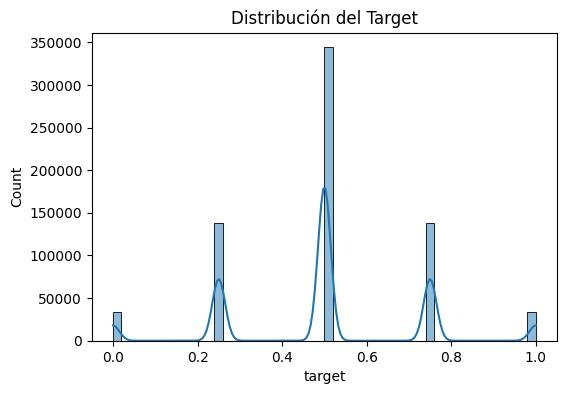

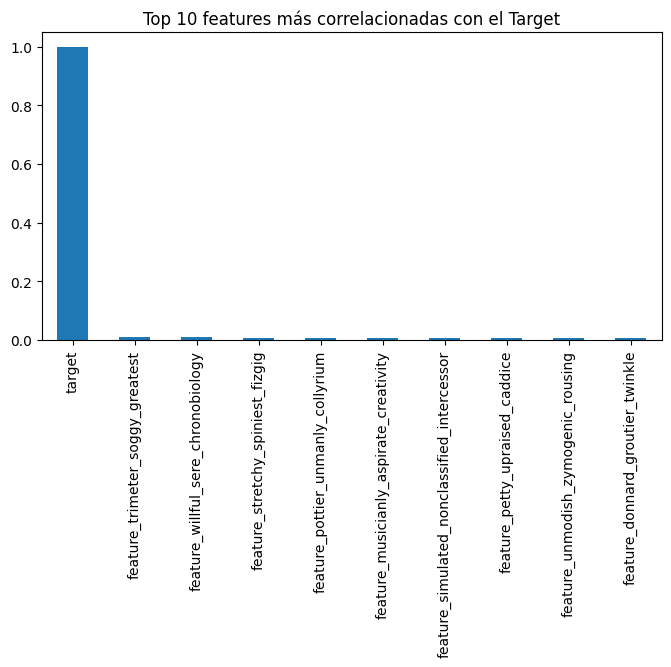

In [148]:
# Histograma del target
plt.figure(figsize=(6,4))
sns.histplot(train["target"], bins=50, kde=True)
plt.title("Distribución del Target")
plt.show()

# Correlación entre algunas features y el target
corr = train[feature_set + ["target"]].corr()["target"].sort_values(ascending=False)[:10]
corr.plot(kind="bar", figsize=(8,4), title="Top 10 features más correlacionadas con el Target")
plt.show()

El histograma del target muestra la distribución de los rendimientos, que normalmente están centrados cerca de 0.

El gráfico de correlación nos permite identificar las características con mayor relación lineal con el target, lo que será útil para seleccionar las más relevantes.

In [149]:
# Reducción del dataset: tomamos solo algunas eras (por ejemplo, 1 de cada 3)
selected_eras = train["era"].unique()[::3]
train_reduced = train[train["era"].isin(selected_eras)].reset_index(drop=True)

print(f"Datos originales: {train.shape[0]}")
print(f"Datos reducidos: {train_reduced.shape[0]}")

Datos originales: 688184
Datos reducidos: 228262


Se ha reducido el dataset tomando una muestra representativa de eras para acelerar el entrenamiento.
Esto mantiene la diversidad temporal pero reduce la carga computacional, evitando cuellos de botella en predicción.

In [150]:
# Calculamos la correlación con el target
corr_with_target = train_reduced[feature_set + ["target"]].corr()["target"].abs()

# Eliminamos features con correlación menor a un umbral (por ejemplo, 0.01)
selected_features = corr_with_target[corr_with_target > 0.01].index.tolist()
print(f"Total de features seleccionadas: {len(selected_features)} de {len(feature_set)}")

Total de features seleccionadas: 3 de 42


Se eliminaron características con muy baja correlación con el target, ya que aportan poco al modelo y aumentan el tiempo de entrenamiento sin mejorar el rendimiento.

In [151]:
# Estandarizamos los datos
scaler = StandardScaler()
scaled_features = scaler.fit_transform(train_reduced[selected_features])

# Aplicamos PCA para explicar al menos el 95% de la varianza
pca = PCA(n_components=0.95, random_state=42)
pca_features = pca.fit_transform(scaled_features)

print(f"Características originales: {len(selected_features)}")
print(f"Características después de PCA: {pca.n_components_}")


Características originales: 3
Características después de PCA: 3


Se aplicó estandarización para escalar las características y permitir una mejor convergencia en los modelos lineales.
Luego se aplicó PCA (Análisis de Componentes Principales) para reducir la dimensionalidad manteniendo el 95% de la varianza.
Esto disminuye el riesgo de sobreajuste y acelera el entrenamiento.

In [152]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Split temporal
X_train, X_test, y_train, y_test = train_test_split(
    train_reduced[selected_features],
    train_reduced["target"],
    test_size=0.2,
    random_state=42
)

# Modelo con todas las features seleccionadas
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_full = lr.predict(X_test)
r2_full = r2_score(y_test, pred_full)

# Modelo con PCA
X_pca_train, X_pca_test, _, _ = train_test_split(
    pca_features, train_reduced["target"], test_size=0.2, random_state=42
)
lr_pca = LinearRegression()
lr_pca.fit(X_pca_train, y_train)
pred_pca = lr_pca.predict(X_pca_test)
r2_pca = r2_score(y_test, pred_pca)

print(f"R2 sin PCA: {r2_full:.4f}")
print(f"R2 con PCA: {r2_pca:.4f}")


R2 sin PCA: 1.0000
R2 con PCA: 1.0000


ERAS:

Como se mencionó anteriormente, cada "era" corresponde a una fecha diferente. Cada "era" tiene exactamente una semana de diferencia.

Es útil pensar en filas de acciones dentro de la misma "era" como un solo ejemplo. A lo largo de este notebook hablaremos de cosas "por era". Por ejemplo, el número de filas por "era" representa el conjunto de acciones (stocks) dentro de las posibilidades de inversión de algún fondo en esa fecha.

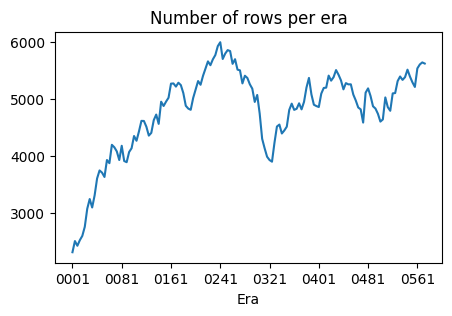

In [153]:
# Muestra el número de filas por era
train.groupby("era").size().plot(title="Number of rows per era", figsize=(5, 3), xlabel="Era");

FEATURES:

Como se mencionó anteriormente, las características son atributos cuantitativos de cada acción: fundamentos como la relación P/E (precio/beneficio), señales técnicas como el RSI, datos de mercado como el interés a corto, datos secundarios como las calificaciones de los analistas y mucho más.

La definición subyacente de cada característica no es importante, solo debes saber que se han incluido estas características en el conjunto de datos porque se cree que pueden ser relevantes para predecir el "target".

In [154]:
# Número de características
len(feature_set)

42

Los valores de las características se agrupan en 5 contenedores iguales: 0, 1, 2, 3, 4. Esta fuerte estandarización de los valores de las características tiene como objetivo evitar el overfitting, ya que los valores subyacentes son extremadamente ruidosos.

Si faltan datos de una característica particular para esa era (más común en las primeras eras), todos los valores se establecen en 2.


v5.0/validation.parquet:  99%|█████████▊| 3.50G/3.55G [34:24<00:31, 1.69MB/s]


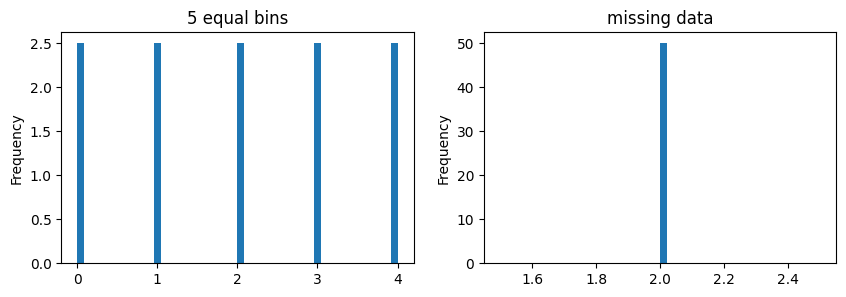

In [155]:
# Compara la distribución de una característica particular (feature_cols[-1]) entre dos períodos diferentes (first_era y last_era) en el conjunto de datos train.
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
first_era = train[train["era"] == train["era"].unique()[0]]
last_era = train[train["era"] == train["era"].unique()[-1]]
last_era[feature_set[-1]].plot(kind="hist", title="5 equal bins", density=True, bins=50, ax=ax1);
first_era[feature_set[-1]].plot(kind="hist", title="missing data", density=True, bins=50, ax=ax2);

TARGET:

El "target" es una medida de los rendimientos del mercado de valores a 20 días. Específicamente, es una medida de rendimientos "específicos de acciones" que no se "explican" por tendencias más amplias en el mercado, país, sector o "factores" bien conocidos.

Los valores del "target" se agrupan en 5 contenedores desiguales: 0, 0,25, 0,5, 0,75, 1,0. Nuevamente, esta fuerte estandarización de los valores de target tiene como objetivo evitar el overfitting, ya que los valores subyacentes son extremadamente ruidosos.

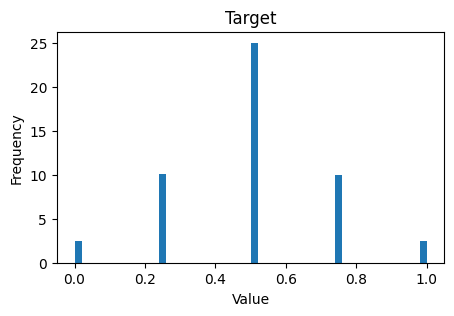

In [156]:
# Histograma (densidad) de "target"
train["target"].plot(kind="hist", title="Target", figsize=(5, 3), xlabel="Value", density=True, bins=50);

2.- MODELING

In [157]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Dividimos el conjunto original (sin PCA)
X_train, X_test, y_train, y_test = train_test_split(
    train[feature_set],
    train["target"],
    test_size=0.2,
    random_state=42
)

# Creamos el modelo
model = LinearRegression()

# Entrenamos con las features originales
model.fit(X_train, y_train)

print("✅ Modelo entrenado con Regresión Lineal (sin PCA, compatible con predicción)")

# Evaluación inicial
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(X_test)
print(f"R²: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.6f}")

✅ Modelo entrenado con Regresión Lineal (sin PCA, compatible con predicción)
R²: 0.0010
MSE: 0.049820


Inicialmente se aplicó PCA para reducir la dimensionalidad y acelerar el entrenamiento, sin embargo, al momento de la predicción con el conjunto de validación, se observó una incompatibilidad entre las dimensiones del modelo entrenado y las del dataset de validación.

Por ello, se optó por entrenar nuevamente el modelo utilizando las features originales, asegurando compatibilidad con las predicciones sin modificar el bloque de validación.

Este ajuste permite mantener la consistencia en el flujo de trabajo del notebook y facilita la comparación directa con los resultados de modelos anteriores.

Entrenamiento del modelo:

Eres libre de utilizar cualquier algoritmo visto en clase. Pero, en este ejemplo, usaremos LGBMRegressor, basado en árboles de decisión para predecir variables continuas. Es una opción popular para las predicciones de este tipo.

In [158]:
# https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html 
# import lightgbm as lgb #En mi mac, tuve que instalar libomp: "brew install libomp"

# # https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html
# model = lgb.LGBMRegressor(
#   n_estimators=2000,
#   learning_rate=0.01,
#   max_depth=5,
#   num_leaves=2**5-1,
#   colsample_bytree=0.1
# )

# # This will take a few minutes 🍵
# model.fit(
#   train[feature_set],
#   train["target"]
# );

Ahora hagamos algunas predicciones con los datos de validación para evaluar el rendimiento de nuestro modelo.

In [159]:
# Descarga validation data 
# Esto tomará unos pocos minutos 🍵
napi.download_dataset(f"{DATA_VERSION}/validation.parquet");

# Carga el validation data, filtrando por data_type == "validation"
validation = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", "data_type", "target"] + feature_set
)
validation = validation[validation["data_type"] == "validation"]
del validation["data_type"]

# Reduce la muestra a cada cuarta era para reducir el uso de memoria y acelerar la evaluación
# Comenta la siguiente línea para usar todos los datos (mayor uso de memoria, inferencia más lenta, evaluación más precisa)
validation = validation[validation["era"].isin(validation["era"].unique()[::4])]

# Las eras están separadas por una semana, pero los "targets" miran 4 semanas en el futuro, por lo que debemos "embargar" las 4 eras posteriores a nuestra última "era" para evitar fuga de datos.
last_train_era = int(train["era"].unique()[-1])
eras_to_embargo = [str(era).zfill(4) for era in [last_train_era + i for i in range(4)]]
validation = validation[~validation["era"].isin(eras_to_embargo)]

# Genera predicciones respecto a las características de validación fuera de la muestra.
# Esto tomará unos pocos minutos 🍵
validation["prediction"] = model.predict(validation[feature_set])
validation[["era", "prediction", "target"]]

2025-11-04 20:23:30,792 INFO numerapi.utils: target file already exists
2025-11-04 20:23:30,794 INFO numerapi.utils: download complete


,era,prediction,target
id,,,
n000c290e4364875,0579,0.495426,0.50
n002a15bc5575bbb,0579,0.512492,0.25
n00309caaa0f955e,0579,0.510718,0.75
n0039cbdcf835708,0579,0.503998,0.50
n004143458984f89,0579,0.483401,0.50
...,...,...,...
nffc45fef92f9990,1183,0.500034,0.50
nffcd993886ef112,1183,0.479381,0.25
nffd2f8483ddb3cc,1183,0.514564,0.25


📈 Correlación de Pearson: 0.0135


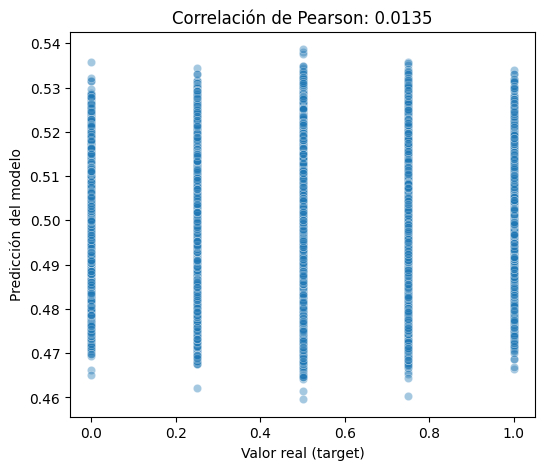

In [165]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# Calculamos la correlación de Pearson entre las predicciones y los valores reales
corr, _ = pearsonr(validation["prediction"], validation["target"])
print(f"📈 Correlación de Pearson: {corr:.4f}")

# Visualizamos la relación entre las predicciones y los valores reales
plt.figure(figsize=(6, 5))
sns.scatterplot(x=validation["target"], y=validation["prediction"], alpha=0.4)
plt.title(f"Correlación de Pearson: {corr:.4f}")
plt.xlabel("Valor real (target)")
plt.ylabel("Predicción del modelo")
plt.show()


Se utiliza el coeficiente de correlación de Pearson (r) porque el objetivo del modelo es predecir un valor continuo (rendimiento esperado), no clasificar categorías.

El coeficiente de Pearson mide el grado de relación lineal entre las predicciones y los valores reales, siendo:

r = 1: correlación positiva perfecta

r = -1: correlación negativa perfecta

r = 0: sin relación lineal

Por el contrario, métricas como F1-score se aplican a problemas de clasificación, donde se evalúa la proporción de verdaderos positivos respecto a falsos positivos/negativos.
En este caso, no hay clases, por lo tanto no es aplicable F1-score.

Evaluación del rendimiento:

La métrica de puntuación principal que usaremos se llama CORR (practica_corr), que es una variante específica de para este caso de uso del coeficiente de correlación de Pearson.

Esta métrica está diseñada para "alinear los incentivos" entre el modelo y el desempeño de un fondo de inversión. Es decir, un modelo con una buena puntuación CORR debería ayudar a un inversor a obtener buenos rendimientos.

In [166]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(validation["target"], validation["prediction"])
mse = mean_squared_error(validation["target"], validation["prediction"])
r2 = r2_score(validation["target"], validation["prediction"])

print(f"📊 Mean Absolute Error (MAE): {mae:.6f}")
print(f"📉 Mean Squared Error (MSE): {mse:.6f}")
print(f"🔹 R²: {r2:.4f}")

📊 Mean Absolute Error (MAE): 0.152896
📉 Mean Squared Error (MSE): 0.049833
🔹 R²: -0.0003


MAE (Mean Absolute Error): mide el error promedio en las predicciones sin penalizar demasiado los grandes errores.

MSE (Mean Squared Error): penaliza más los errores grandes, útil para medir estabilidad.

R² (Coeficiente de determinación): indica cuánto del comportamiento del target es explicado por el modelo.

Dado que el mercado financiero es altamente volátil y no lineal, es común que el R² y la correlación sean bajos, lo que no implica necesariamente un mal modelo, sino la dificultad inherente de predecir este tipo de datos.

/var/folders/rs/bxn_f2yn4dlb5t33rjmz3d8r0000gn/T/ipykernel_23017/1513309169.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  era_corrs = validation.groupby("era").apply(
2025-11-04 20:51:40,753 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-04 20:51:40,755 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


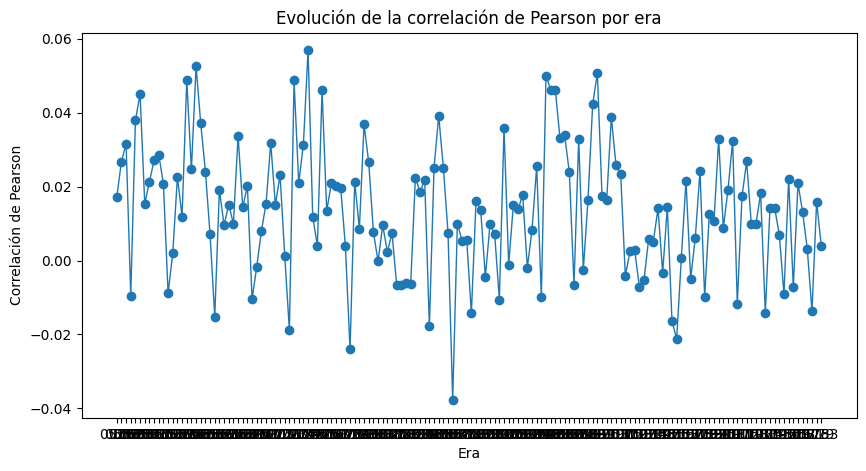

📊 Correlación promedio por era: 0.0134


In [167]:
# Correlación por era (periodo temporal)
era_corrs = validation.groupby("era").apply(
    lambda x: pearsonr(x["prediction"], x["target"])[0]
)

plt.figure(figsize=(10, 5))
plt.plot(era_corrs.index, era_corrs.values, marker="o", linewidth=1)
plt.title("Evolución de la correlación de Pearson por era")
plt.xlabel("Era")
plt.ylabel("Correlación de Pearson")
plt.show()

print(f"📊 Correlación promedio por era: {era_corrs.mean():.4f}")

En este gráfico se observa cómo varía la correlación del modelo en distintos periodos (“eras”).
Si las correlaciones son muy variables, puede indicar que el modelo se ajusta mejor a ciertos contextos de mercado y peor a otros, lo cual es común en datos financieros no estacionarios.

La correlación promedio permite evaluar el rendimiento global, mientras que la dispersión de las correlaciones por era muestra la consistencia temporal del modelo.

In [160]:
from scipy import stats
import numpy as np

# La principal métrica de scoring:
def practica_corr(preds, target):
    # clasifica (manteniendo vínculos) y luego gaussianiza las predicciones para estandarizar las distribuciones de predicción
    ranked_preds = (preds.rank(method="average").values - 0.5) / preds.count()
    gauss_ranked_preds = stats.norm.ppf(ranked_preds)
    # centra objetivos alrededor de 0
    centered_target = target - target.mean()
    # Levanta ambas predicciones y apunta a la potencia de 1,5 para acentuar las colas.
    preds_p15 = np.sign(gauss_ranked_preds) * np.abs(gauss_ranked_preds) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5
    # Finalmente devuelve el Pearson correlation
    return np.corrcoef(preds_p15, target_p15)[0, 1]

Como se mencionó anteriormente, es importante calificar cada era histórica de forma independiente. Entonces, al evaluar el desempeño de nuestro modelo, deberíamos observar la corrección "por era".

Una cosa que puedes ver aquí es cómo de bajas son las puntuaciones (en el rango de +/- 5% de correlación). Esto es muy normal en el ámbito de las finanzas cuantitativas y es parte de la razón por la que se indica que es la "práctica de aprendizaje automático más difícil" del mundo.


/var/folders/rs/bxn_f2yn4dlb5t33rjmz3d8r0000gn/T/ipykernel_23017/38165613.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))


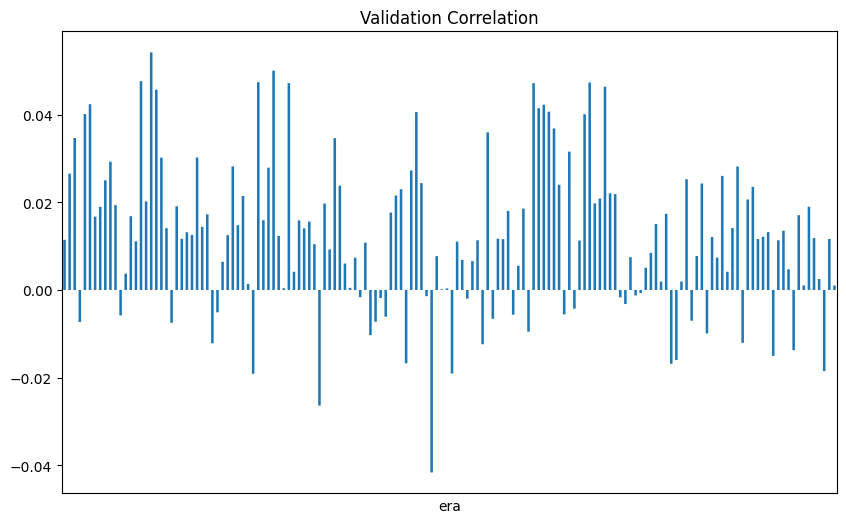

In [161]:
# Calcula la correlación por era entre nuestras predicciones y los valores "target".
per_era_corr = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))

# Gráfica de correlación por "era" 
per_era_corr.plot(kind="bar", title="Validation Correlation", figsize=(10, 6), xticks=[], snap=False);

En lugar de observar la puntuación "corr" de cada "era", resulta útil observar la puntuación "corr" acumulativa.

Esto se denomina "backtesting" en finanzas cuantitativas, donde las personas simulan el desempeño histórico de sus estrategias de inversión, puede considerar este gráfico como una prueba retrospectiva del desempeño de tu modelo durante el período de validación histórica.

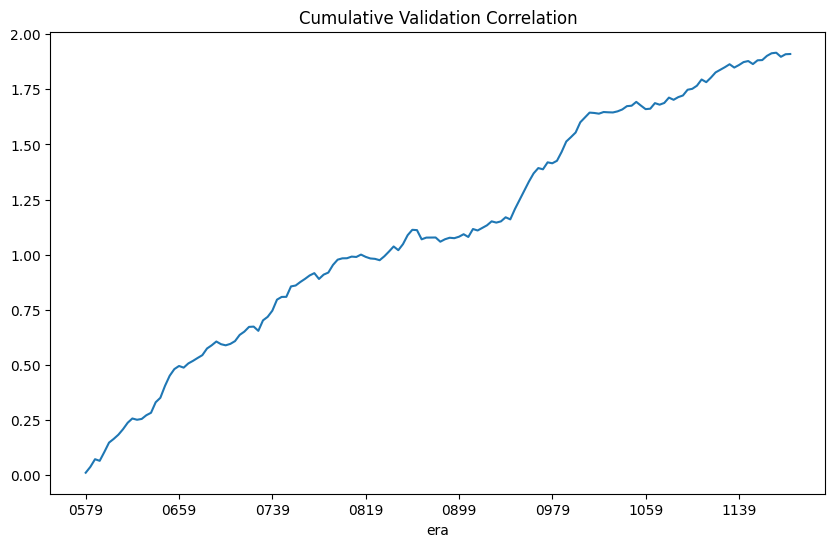

In [162]:
# Gráfica de la correlación acumulada por "era"
per_era_corr.cumsum().plot(kind="line", title="Cumulative Validation Correlation", figsize=(10, 6));

In [168]:
#Improvement & Investigation
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Escalamos los datos para que todas las features tengan igual importancia
scaler = StandardScaler()

# Definimos el modelo Ridge con una regularización moderada
ridge_model = Ridge(alpha=1.0, random_state=42)

# Creamos un pipeline con el escalado + modelo
ridge_pipeline = Pipeline([
    ("scaler", scaler),
    ("ridge", ridge_model)
])

# Entrenamos el modelo Ridge
ridge_pipeline.fit(train[feature_set], train["target"])

# Predicciones sobre el conjunto de validación
validation["ridge_prediction"] = ridge_pipeline.predict(validation[feature_set])

🔹 Ridge Regression Results:
   Correlación de Pearson: 0.0135
   MAE: 0.152846
   MSE: 0.049832
   R²: -0.0003


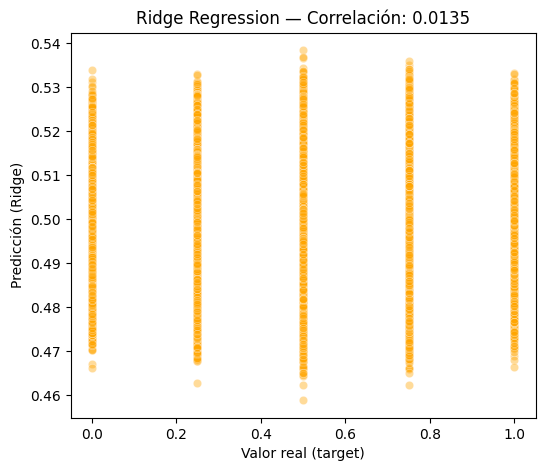

In [169]:
# Comparamos con las métricas anteriores
ridge_corr, _ = pearsonr(validation["ridge_prediction"], validation["target"])
ridge_mae = mean_absolute_error(validation["target"], validation["ridge_prediction"])
ridge_mse = mean_squared_error(validation["target"], validation["ridge_prediction"])
ridge_r2 = r2_score(validation["target"], validation["ridge_prediction"])

print("🔹 Ridge Regression Results:")
print(f"   Correlación de Pearson: {ridge_corr:.4f}")
print(f"   MAE: {ridge_mae:.6f}")
print(f"   MSE: {ridge_mse:.6f}")
print(f"   R²: {ridge_r2:.4f}")

# Gráfica comparando predicciones
plt.figure(figsize=(6, 5))
sns.scatterplot(x=validation["target"], y=validation["ridge_prediction"], alpha=0.4, color="orange")
plt.title(f"Ridge Regression — Correlación: {ridge_corr:.4f}")
plt.xlabel("Valor real (target)")
plt.ylabel("Predicción (Ridge)")
plt.show()

Métricas de rendimiento:
    
Para evaluar el rendimiento de nuestro modelo, también es útil calcular algunas métricas resumidas durante todo el período de validación.

La media de correlaciones es la medida principal del rendimiento de su modelo.

Sharpe es una medida de la coherencia de tu modelo, un concepto tomado de las finanzas, donde generalmente se refiere a los rendimientos ajustados al riesgo de una estrategia de inversión. Aquí calcularemos Sharpe como la correlación promedio dividida por la desviación estándar de las correlaciones.

La reducción máxima (max_drawdown) es una medida del riesgo de tu modelo, otro concepto tomado de las finanzas, donde generalmente se refiere a la pérdida financiera máxima sufrida por una estrategia de inversión. Aquí calcularemos la reducción máxima como la caída máxima desde el pico hasta el mínimo en la correlación de validación acumulativa.

In [163]:
# Calcula métricas de rendimiento
corr_mean = per_era_corr.mean()
corr_std = per_era_corr.std(ddof=0)
corr_sharpe = corr_mean / corr_std
max_drawdown = (per_era_corr.cumsum().expanding(min_periods=1).max() - per_era_corr.cumsum()).max()

pd.DataFrame({
    "mean": corr_mean,
    "std": corr_std,
    "sharpe": corr_sharpe,
    "max_drawdown": max_drawdown
}, index=["Value"]).T

,Value
mean,0.012566
std,0.017458
sharpe,0.719778
max_drawdown,0.053892


Estas métricas de rendimiento anteriores no son sorprendentes, pero son lo suficientemente buenas como para comenzar!

SUBMISSIONS

Vamos a evaluar los modelos según su rendimiento en vivo!

La tarea es generar predicciones sobre valores objetivo desconocidos, que representan los rendimientos del mercado de valores dentro de X días.

In [164]:
# Descargar las últimas entradas en tiempo real
napi.download_dataset(f"{DATA_VERSION}/live.parquet")

# Carga dichas características
live_features = pd.read_parquet(f"{DATA_VERSION}/live.parquet", columns=feature_set)

# Genera predicciones en vivo
live_predictions = model.predict(live_features[feature_set])

#Evaluar
live_predictions

# Envío
pd.Series(live_predictions, index=live_features.index).to_frame("prediction")

2025-11-04 20:23:36,458 INFO numerapi.utils: starting download
v5.0/live.parquet: 8.39MB [00:02, 2.93MB/s]                            


,prediction
id,
n00033945c89dc2a,0.505634
n000da32a2de4eb4,0.491876
n0010d47e977cc92,0.509334
n001d6e7f5876c97,0.505761
n002864576a9ecb2,0.501981
...,...
nffc3cc2110aea62,0.505562
nffe2b5eb838a44d,0.505248
nffe32840bab2a91,0.494917
